In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_least_rmsd)=
# Get least RMSD

*Getting the least RMSD of a molecular system from a reference structure after optimal superimposition.*

The function {func}`molsysmt.structure.get_least_rmsd` calculates the root-mean-square deviation (RMSD) between structures after finding the optimal translation and rotation that minimizes coordinate differences (using the quaternion-based algorithm by Coutsias et al.).

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.get_least_rmsd`.
:::


## Basic usage

Let's show how to calculate the least RMSD along a pentalanine simulation trajectory with respect to the initial configuration:


In [2]:
import molsysmt as msm
import numpy as np
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5'], to_form='molsysmt.MolSys')


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We compute both the unaligned standard RMSD and the optimal least RMSD (LRMSD) for the backbone atoms:


In [4]:
rmsd = msm.structure.get_rmsd(molsys, selection='backbone', reference_structure_index=0)
lrmsd = msm.structure.get_least_rmsd(molsys, selection='backbone', reference_structure_index=0)
time = msm.get(molsys, element='system', time=True)
time_ns = msm.pyunitwizard.convert(time, to_unit='ns')


We plot the unaligned RMSD versus the optimal least RMSD across the entire simulation:


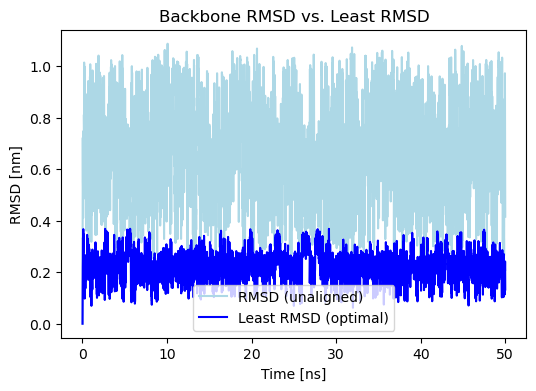

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(time_ns, rmsd, label='RMSD (unaligned)', color='lightblue')
plt.plot(time_ns, lrmsd, label='Least RMSD (optimal)', color='blue')
plt.xlabel('Time [ns]')
plt.ylabel('RMSD [nm]')
plt.title('Backbone RMSD vs. Least RMSD')
plt.legend()
plt.show()


## Comparing against an external reference structure

We can compute the least RMSD with respect to an external reference molecular system using `reference_molecular_system`:


In [6]:
native_ref = msm.extract(molsys, structure_indices=0)
lrmsd_ref = msm.structure.get_least_rmsd(molsys, selection='backbone', reference_molecular_system=native_ref)
print('Mean LRMSD to native reference:', np.mean(lrmsd_ref))


Mean LRMSD to native reference: 0.2224203571949468 nanometer


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get RMSD <Tutorial_Get_rmsd>`: Calculate standard root-mean-square deviation with {func}`molsysmt.structure.get_rmsd`.
- {ref}`Get <Tutorial_Get>`: Query simulation times and system attributes with {func}`molsysmt.basic.get`.
- {ref}`Least RMSD fit <Tutorial_Least_rmsd_fit>`: Superimpose coordinate frames to minimize RMSD with {func}`molsysmt.structure.least_rmsd_fit`.
- {ref}`Least RMSD align <Tutorial_Least_rmsd_align>`: Align structures over a reference system with {func}`molsysmt.structure.least_rmsd_align`.
:::
